In [1]:
import pandas as pd
path = '..\\Data\\Raw\\train_news.csv'
df = pd.read_csv(path)
print(df.head())
print(df.columns)
print(df.shape)
print(df.dtypes)

   Unnamed: 0     id                                           headline  \
0           0   9653  Ethics Questions Dogged Agriculture Nominee as...   
1           1  10041  U.S. Must Dig Deep to Stop Argentina’s Lionel ...   
2           2  19113  Cotton to House: ’Do Not Walk the Plank and Vo...   
3           3   6868  Paul LePage, Besieged Maine Governor, Sends Co...   
4           4   7596                       A Digital 9/11 If Trump Wins   

                   written_by  \
0  Eric Lipton and Steve Eder   
1             David Waldstein   
2                     Pam Key   
3                Jess Bidgood   
4           Finian Cunningham   

                                                news  label  
0  WASHINGTON  —   In Sonny Perdue’s telling, Geo...      0  
1  HOUSTON  —   Venezuela had a plan. It was a ta...      0  
2  Sunday on ABC’s “This Week,” while discussing ...      0  
3  AUGUSTA, Me.  —   The beleaguered Republican g...      0  
4    Finian Cunningham has written exten

In [2]:
# checking for null and unique values
print(df.isna().sum())
print(df['label'].value_counts())
print(df['id'].nunique())


Unnamed: 0       0
id               0
headline       558
written_by    1957
news            39
label            0
dtype: int64
label
1    10413
0    10387
Name: count, dtype: int64
20800


In [3]:
print(df.duplicated().sum())

0


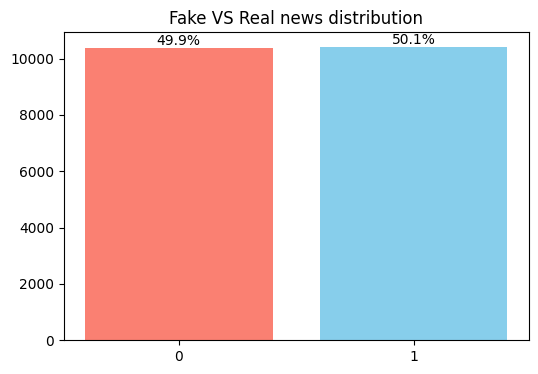

In [4]:
import matplotlib.pyplot as plt

# counts values and percentage 
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100
#  plot
plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])
# labels
plt.xlabel('')
plt.ylabel('')
plt.title('Fake VS Real news distribution')
# Add percentage on top of bars
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )
plt.xticks(ticks=counts.index, labels=counts.index)

plt.show()

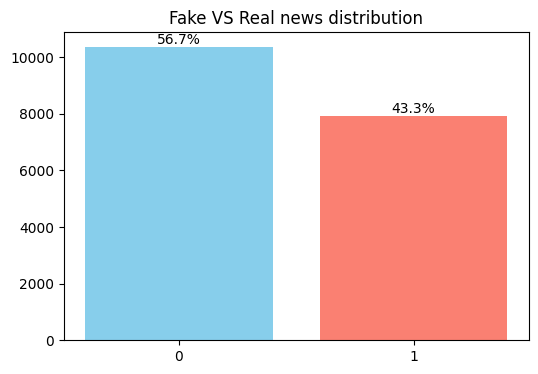

In [5]:
# visulize distrubution of target after renoving of null values
new_df = df.dropna(axis=0)
import matplotlib.pyplot as plt

# counts values and percentage 
counts = new_df['label'].value_counts()
percentages = new_df['label'].value_counts(normalize=True) * 100
#  plot
plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])
# labels
plt.xlabel('')
plt.ylabel('')
plt.title('Fake VS Real news distribution')
# Add percentage on top of bars
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )
plt.xticks(ticks=counts.index, labels=counts.index)

plt.show()

       min_length  max_length  Average_length
label                                        
0             3.0     85948.0     5214.130259
1             1.0    142961.0     3890.471467


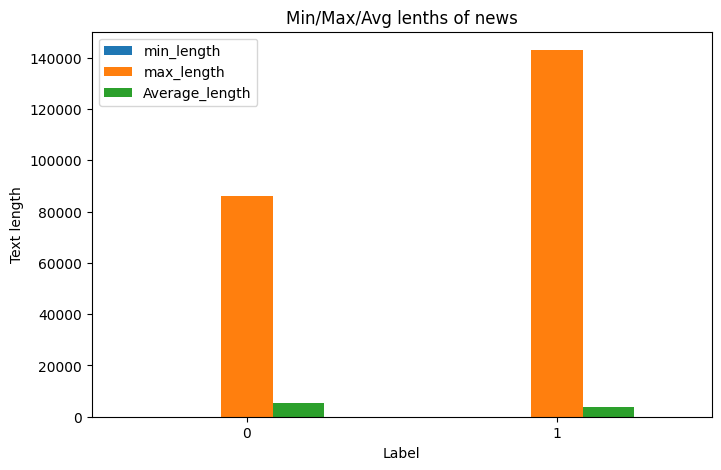

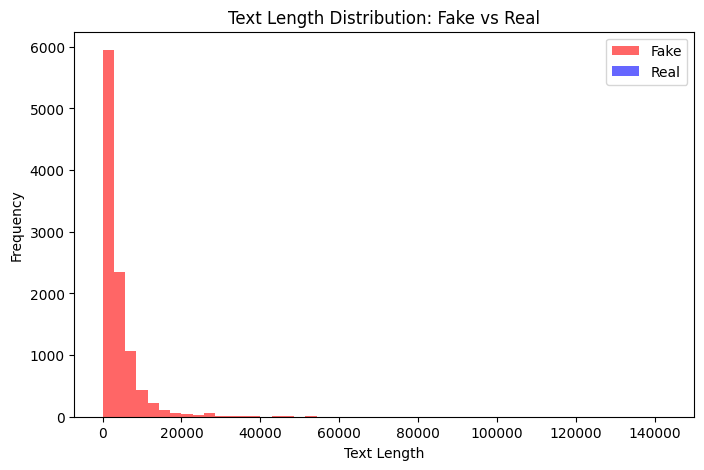

In [6]:
# Obseerving fake vs real text lenhth
df['news_length'] = df['news'].str.len()
group_stats = df.groupby('label')['news_length'].agg(min_length = 'min', max_length = 'max', Average_length = 'mean')
print(group_stats)
group_stats.plot(kind = 'bar', figsize = (8, 5))
plt.xlabel("Label")
plt.ylabel("Text length")
plt.title("Min/Max/Avg lenths of news")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,5))

df[df['label']==1]['news_length'].plot(
    kind='hist', bins=50, alpha=0.6, label='Fake', color='red'
)

df[df['label']=='0']['news_length'].plot(
    kind='hist', bins=50, alpha=0.6, label='Real',color='blue' 
)

plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Text Length Distribution: Fake vs Real')
plt.legend()
plt.show()


In [7]:
# common words analysis
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
fake_news = new_df[new_df['label'] == 1]['news']
real_news = new_df[new_df['label'] == 0]['news']

def get_common_words(news_series, n=20):
    words = " ".join(news_series).lower().split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return Counter(words).most_common(n)

f_n = get_common_words(fake_news, 10)
r_n = get_common_words(real_news, 10)
print("Fake news common words :",f_n)
print("Real news common words :",r_n)

Fake news common words : [('trump', 11590), ('people', 11300), ('clinton', 11272), ('hillary', 8951), ('–', 8881), ('just', 8726), ('new', 8241), ('like', 8080), ('.', 7687), (',', 7642)]
Real news common words : [('mr.', 64109), ('”', 45463), ('said', 39271), ('—', 38756), ('trump', 22598), ('new', 19117), ('said.', 18783), ('people', 15684), ('like', 14817), ('president', 13061)]
